# Chatbot with Collection Schema 

## Review

We extended our chatbot to save semantic memories to a single [user profile](https://docs.langchain.com/oss/python/concepts/memory#profile). 

We also introduced a library, [Trustcall](https://github.com/hinthornw/trustcall), to update this schema with new information. 

## Goals

Sometimes we want to save memories to a [collection](https://docs.google.com/presentation/d/181mvjlgsnxudQI6S3ritg9sooNyu4AcLLFH1UK0kIuk/edit#slide=id.g30eb3c8cf10_0_200) rather than single profile. 

Here we'll update our chatbot to [save memories to a collection](https://docs.langchain.com/oss/python/concepts/memory#collection).

We'll also show how to use Trustcall to update this collection. 


## Defining a collection schema

Instead of storing user information in a fixed profile structure, we'll create a flexible collection schema to store memories about user interactions.

Each memory will be stored as a separate entry with a single `content` field for the main information we want to remember

This approach allows us to build an open-ended collection of memories that can grow and change as we learn more about the user.

We can define a collection schema as a [Pydantic](https://docs.pydantic.dev/latest/) object. 

In [9]:
from pydantic import BaseModel, Field

class Memory(BaseModel):
    """Schema for storing a single memory or fact about the user."""
    content: str = Field(description="The main content of the memory. For example: User expressed interest in learning about French.")

class MemoryCollection(BaseModel):
    """A collection of memories about the user."""
    memories: list[Memory] = Field(description="A list of memories about the user.")

We can used LangChain's chat model  [chat model](https://docs.langchain.com/oss/python/langchain/models) interface's [`with_structured_output`](https://docs.langchain.com/oss/python/langchain/models#structured-outputs) method to enforce structured output.

In [10]:
from langchain_core.messages import HumanMessage
from langchain.chat_models import init_chat_model

# Initialize the model
model = init_chat_model(
    model="openai/gpt-oss-120b",
    model_provider="groq",
    temperature=0
)
# Bind schema to model
model_with_structure = model.with_structured_output(MemoryCollection)

# Invoke the model to produce structured output that matches the schema
memory_collection = model_with_structure.invoke([HumanMessage("My name is Lucas. I like to bike.")])
memory_collection.memories

[Memory(content="User's name is Lucas."),
 Memory(content='User likes to bike.')]

We can use `model_dump()` to serialize a Pydantic model instance into a Python dictionary.

In [11]:
memory_collection.memories[0].model_dump()

{'content': "User's name is Lucas."}

Save dictionary representation of each memory to the store. 

In [12]:
import uuid
from langgraph.store.memory import InMemoryStore

# Initialize the in-memory store
in_memory_store = InMemoryStore()

# Namespace for the memory to save
user_id = "1"
namespace_for_memory = (user_id, "memories")

# Save a memory to namespace as key and value
key = str(uuid.uuid4())
value = memory_collection.memories[0].model_dump()
in_memory_store.put(namespace_for_memory, key, value)

key = str(uuid.uuid4())
value = memory_collection.memories[1].model_dump()
in_memory_store.put(namespace_for_memory, key, value)

Search for memories in the store. 

In [13]:
# Search 
for m in in_memory_store.search(namespace_for_memory):
    print(m.dict())

{'namespace': ['1', 'memories'], 'key': '6319d18e-7ab3-4d41-9094-181c9f1a686a', 'value': {'content': "User's name is Lucas."}, 'created_at': '2026-09-18T17:29:57.671876+00:00', 'updated_at': '2026-09-18T17:29:57.671878+00:00', 'score': None}
{'namespace': ['1', 'memories'], 'key': '02b33654-7148-4d17-9f53-fdba9dc6be68', 'value': {'content': 'User likes to bike.'}, 'created_at': '2026-09-18T17:29:57.671955+00:00', 'updated_at': '2026-09-18T17:29:57.671956+00:00', 'score': None}


## Updating collection schema

We discussed the challenges with updating a profile schema in the last lesson. 

The same applies for collections! 

We want the ability to update the collection with new memories as well as update existing memories in the collection. 

Now we'll show that [Trustcall](https://github.com/hinthornw/trustcall) can be also used to update a collection. 

This enables both addition of new memories as well as [updating existing memories in the collection](https://github.com/hinthornw/trustcall?tab=readme-ov-file#simultanous-updates--insertions
).

Let's define a new extractor with Trustcall. 

As before, we provide the schema for each memory, `Memory`.  

But, we can supply `enable_inserts=True` to allow the extractor to insert new memories to the collection. 

In [15]:
from trustcall import create_extractor

# Create the extractor
trustcall_extractor = create_extractor(
    model,
    tools=[Memory],
    tool_choice="Memory",
    enable_inserts=True,
)

In [ ]:
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage

# Instruction
instruction = """Extract memories from the following conversation:"""

# Conversation
conversation = [HumanMessage(content="Hi, I'm Lance."),  
                AIMessage(content="Nice to meet you, Lance."), 
                HumanMessage(content="This morning I had a nice bike ride in San Francisco.")]

# Invoke the extractor
result = trustcall_extractor.invoke({"messages": [SystemMessage(content=instruction)] + conversation})

In [17]:
# Messages contain the tool calls
for m in result["messages"]:
    m.pretty_print()

================================== Ai Message ==================================
Tool Calls:
  Memory (fc_69e30a37-6698-46fb-b441-6f68355bd0bf)
 Call ID: fc_69e30a37-6698-46fb-b441-6f68355bd0bf
  Args:
    content: User's name is Lance.


In [18]:
# Responses contain the memories that adhere to the schema
for m in result["responses"]: 
    print(m)

content="User's name is Lance."


In [19]:
# Metadata contains the tool call  
for m in result["response_metadata"]: 
    print(m)

{'id': 'fc_69e30a37-6698-46fb-b441-6f68355bd0bf'}


In [34]:
# Update the conversation
updated_conversation = [AIMessage(content="That's great, did you do after?"), 
                        HumanMessage(content="I went to Tartine and ate a croissant."),                        
                        AIMessage(content="What else is on your mind?"),
                        HumanMessage(content="I was thinking about my Japan, and going back this winter!"),]

# Update the instruction
system_msg = """Update existing memories and create new ones based on the following conversation:"""

# We'll save existing memories, giving them an ID, key (tool name), and value
tool_name = "Memory"
existing_memories = [(str(i), tool_name, memory.model_dump()) for i, memory in enumerate(result["responses"])] if result["responses"] else None
existing_memories

In [35]:
# Invoke the extractor with our updated conversation and existing memories
result = trustcall_extractor.invoke({"messages": updated_conversation, 
                                     "existing": existing_memories})

In [36]:
# Messages from the model indicate two tool calls were made
for m in result["messages"]:
    m.pretty_print()

================================== Ai Message ==================================
Tool Calls:
  Memory (fc_131f9379-7104-4fc8-bd53-f1545849a419)
 Call ID: fc_131f9379-7104-4fc8-bd53-f1545849a419
  Args:
    content: User is planning to go back to Japan this winter.


In [37]:
# Responses contain the memories that adhere to the schema
for m in result["responses"]: 
    print(m)

content='User is planning to go back to Japan this winter.'


In [38]:
# Metadata contains the tool call  
for m in result["response_metadata"]: 
    print(m)

{'id': 'fc_131f9379-7104-4fc8-bd53-f1545849a419'}


## Chatbot with collection schema updating

Now, let's bring Trustcall into our chatbot to create and update a memory collection.

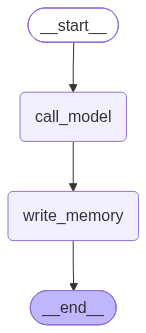

In [ ]:
from IPython.display import Image, display

import uuid

from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.store.memory import InMemoryStore
from langchain_core.messages import merge_message_runs
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.runnables.config import RunnableConfig
from langgraph.checkpoint.memory import MemorySaver
from langgraph.store.base import BaseStore

# Initialize the model
model = init_chat_model(
    model="openai/gpt-oss-120b",
    model_provider="groq",
    temperature=0
)

# Memory schema
class Memory(BaseModel):
    """Schema for storing a single memory or fact about the user."""
    content: str = Field(description="The main content of the memory. For example: User expressed interest in learning about French.")

# Create the Trustcall extractor
trustcall_extractor = create_extractor(
    model,
    tools=[Memory],
    tool_choice="Memory",
    # This allows the extractor to insert new memories
    enable_inserts=True,
)

# Chatbot instruction
MODEL_SYSTEM_MESSAGE = """You are a helpful chatbot. You are designed to be a companion to a user. 

You have a long term memory which keeps track of information you learn about the user over time.

Current Memory (may include updated memories from this conversation): 

{memory}"""

# Trustcall instruction
TRUSTCALL_INSTRUCTION = """Reflect on following interaction. 

Use the provided tools to retain any necessary memories about the user. 

Use parallel tool calling to handle updates and insertions simultaneously:"""

def call_model(state: MessagesState, config: RunnableConfig, store: BaseStore):

    """Load memories from the store and use them to personalize the chatbot's response."""
    
    # Get the user ID from the config
    user_id = config["configurable"]["user_id"]

    # Retrieve memory from the store
    namespace = ("memories", user_id)
    memories = store.search(namespace)

    # Format the memories for the system prompt
    info = "\n".join(f"- {mem.value['content']}" for mem in memories)
    system_msg = MODEL_SYSTEM_MESSAGE.format(memory=info)

    # Respond using memory as well as the chat history
    response = model.invoke([SystemMessage(content=system_msg)]+state["messages"])

    return {"messages": response}

def write_memory(state: MessagesState, config: RunnableConfig, store: BaseStore):

    """Reflect on the chat history and update the memory collection."""
    
    # Get the user ID from the config
    user_id = config["configurable"]["user_id"]

    # Define the namespace for the memories
    namespace = ("memories", user_id)

    # Retrieve the most recent memories for context
    existing_items = store.search(namespace)

    # Format the existing memories for the Trustcall extractor
    tool_name = "Memory"
    existing_memories = ([(existing_item.key, tool_name, existing_item.value)
                          for existing_item in existing_items]
                          if existing_items
                          else None
                        )

    # Merge the chat history and the instruction
    updated_messages=list(merge_message_runs(messages=[SystemMessage(content=TRUSTCALL_INSTRUCTION)] + state["messages"]))

    # Invoke the extractor
    result = trustcall_extractor.invoke({"messages": updated_messages, 
                                        "existing": existing_memories})

    # Save the memories from Trustcall to the store
    for r, rmeta in zip(result["responses"], result["response_metadata"]):
        store.put(namespace,
                  rmeta.get("json_doc_id", str(uuid.uuid4())),
                  r.model_dump(mode="json"),
            )

# Define the graph
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_node("write_memory", write_memory)
builder.add_edge(START, "call_model")
builder.add_edge("call_model", "write_memory")
builder.add_edge("write_memory", END)

# Store for long-term (across-thread) memory
across_thread_memory = InMemoryStore()

# Checkpointer for short-term (within-thread) memory
within_thread_memory = MemorySaver()

# Compile the graph with the checkpointer fir and store
graph = builder.compile(checkpointer=within_thread_memory, store=across_thread_memory)

# View
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [29]:
# We supply a thread ID for short-term (within-thread) memory
# We supply a user ID for long-term (across-thread) memory 
config = {"configurable": {"thread_id": "1", "user_id": "1"}}

# User input 
input_messages = [HumanMessage(content="Hi, my name is Lance")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

Hi, my name is Lance
================================== Ai Message ==================================

Nice to meet you, Lance! I’ve stored your name so I can address you personally in our future chats. How’s your day going so far?


In [30]:
# User input 
input_messages = [HumanMessage(content="I like to bike around San Francisco")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

I like to bike around San Francisco
================================== Ai Message ==================================

That sounds awesome, Lance! 🚴‍♂️  
San Francisco has some great hills and waterfront paths—do you have a favorite route or spot you like to ride to? Maybe the Golden Gate Bridge, the Embarcadero, or a hidden neighborhood street? I'd love to hear about your biking adventures!


Could not find existing schema in dict for memories


In [31]:
# Namespace for the memory to save
user_id = "1"
namespace = ("memories", user_id)
memories = across_thread_memory.search(namespace)
for m in memories:
    print(m.dict())

{'namespace': ['memories', '1'], 'key': '45e5b479-ac4c-4bbb-95cd-3524ed5ea1ba', 'value': {'content': "User's name is Lance"}, 'created_at': '2026-09-18T17:32:01.464630+00:00', 'updated_at': '2026-09-18T17:32:01.464630+00:00', 'score': None}


In [32]:
# User input 
input_messages = [HumanMessage(content="I also enjoy going to bakeries")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

I also enjoy going to bakeries
================================== Ai Message ==================================

That’s a perfect combo—pedal power + fresh pastries! 🍞🚴‍♂️  

Do you have a go‑to bakery you like to stop at after a ride? Maybe a spot near the waterfront or up in the hills? I’m curious about what treats you’re hunting for (croissants, sour‑dough, something sweet, or maybe a coffee to refuel). Feel free to share any favorite names or even a hidden gem you’ve discovered while cruising the city!


Could not find existing schema in dict for memories


Continue the conversation in a new thread.

In [33]:
# We supply a thread ID for short-term (within-thread) memory
# We supply a user ID for long-term (across-thread) memory 
config = {"configurable": {"thread_id": "2", "user_id": "1"}}

# User input 
input_messages = [HumanMessage(content="What bakeries do you recommend for me?")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

What bakeries do you recommend for me?
================================== Ai Message ==================================

Hey Lance! I’d love to point you toward some great bakeries, but I need a little more context to make the recommendations truly useful for you.  

**Could you let me know:**

1. **Where you’re looking for bakeries** (city, neighborhood, or even a specific zip code).  
2. **Any dietary preferences or restrictions** you have (e.g., gluten‑free, vegan, low‑sugar, keto, etc.).  
3. **What you’re in the mood for**—artisan breads, pastries, cakes, cookies, specialty coffee‑paired treats, etc.  
4. **Any particular vibe you enjoy** (cozy café, bustling market stall, upscale patisserie, etc.).  

Once I have those details, I can give you a curated list of spots that match your taste and location. Looking forward to hearing more!


Could not find existing schema in dict for memories
